# Part A : Concept Application

## Import Libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

## Data Loading

In [67]:
def load_scaled_iris():
    """ Load the Iris dataset and scale the features using StandardScaler."""
    iris = load_iris()
    X = iris.data
    y = iris.target
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y

## K-Means

In [68]:
def apply_kmeans(X, k=3):
    """ Apply KMeans clustering to the data and return the cluster labels."""
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    return labels

## Evaluation 

In [69]:
def evaluate_clusters(y_true, y_pred):
    """ Evaluate the clustering results using confusion matrix, ARI, and NMI."""
    cm = confusion_matrix(y_true, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    
    print("Confusion Matrix:")
    print(cm)
    print("ARI:", round(ari, 3))
    print("NMI:", round(nmi, 3))

## Visualization

In [ ]:
def plot_results(X, y_true, y_pred):
    """ Plot the true labels and predicted cluster labels side by side."""
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y_true)
    plt.title("True Labels")
    
    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=y_pred)
    plt.title("K-Means Labels")
    
    plt.show()

## DBSCAN

In [ ]:
def apply_dbscan(X, eps=0.8, min_samples=5):
    """ Apply DBSCAN clustering to the data and return the cluster labels."""
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    return labels

## K-Means Check

Confusion Matrix:
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]
ARI: 0.62
NMI: 0.659


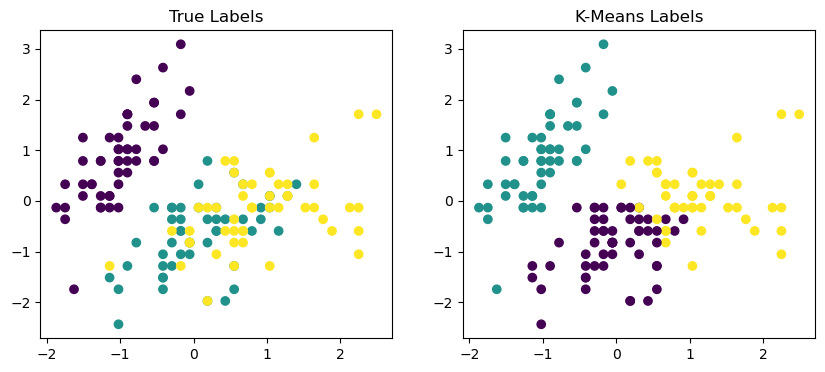

In [72]:
X, y = load_scaled_iris()

kmeans_labels = apply_kmeans(X)

evaluate_clusters(y, kmeans_labels)

plot_results(X, y, kmeans_labels)

## DBSCAN Check

Confusion Matrix:
[[ 0  0  0  0]
 [ 1 49  0  0]
 [ 0  0 50  0]
 [ 3  0 47  0]]
ARI: 0.552
NMI: 0.69


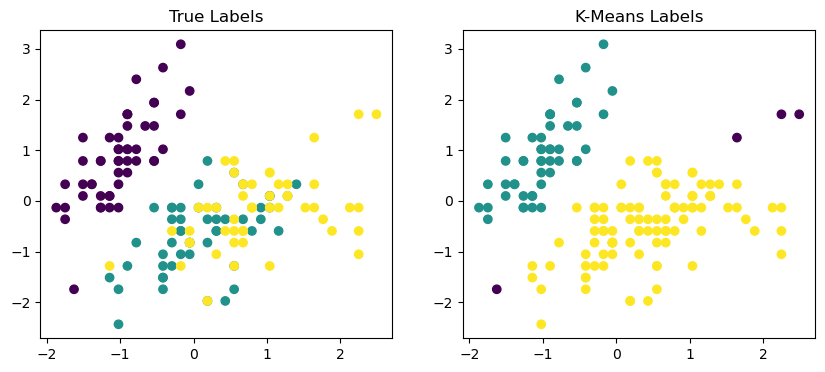

In [73]:
X, y = load_scaled_iris()

dbscan_labels = apply_dbscan(X)
evaluate_clusters(y, dbscan_labels)
plot_results(X, y, dbscan_labels)

K-Means achieves strong agreement with true species labels.
Species 0 is usually perfectly separated, while Species 1 and 2 overlap.
ARI around 0.62 indicates meaningful clustering quality.

DBSCAN may not recover exactly 3 groups because cluster density overlaps.

### When unsupervised clustering agrees with knowm labels, what does it suggest?

When unsupervised clustering agrees with known labels, it suggests that the feature space naturally contains separable structure. This means the variables already encode meaningful grouping patterns even without supervision. Strong agreement indicates the classes are geometrically distinct, while disagreement suggests overlap, noise, or non-spherical boundaries.

# Part B : Stretch Problem

##  Agglomerative Clustering

In [74]:
def apply_agglomerative(X, n_clusters=3):
    """ Apply Agglomerative Clustering to the data and return the cluster labels."""
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(X)
    return labels

## Dendrogram

In [ ]:
def plot_dendrogram(X):
    """ Plot the dendrogram for hierarchical clustering."""
    linkage_matrix = linkage(X, method='ward')

    plt.figure(figsize=(10, 6))
    dendrogram(linkage_matrix)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()


## Evaluate ARI

In [ ]:
def evaluate_ari(true_labels, pred_labels):
    """ Evaluate the clustering results using Adjusted Rand Index (ARI)."""
    return adjusted_rand_score(true_labels, pred_labels)


Agglomerative Clustering ARI: 0.6153
K-Means ARI: 0.6201


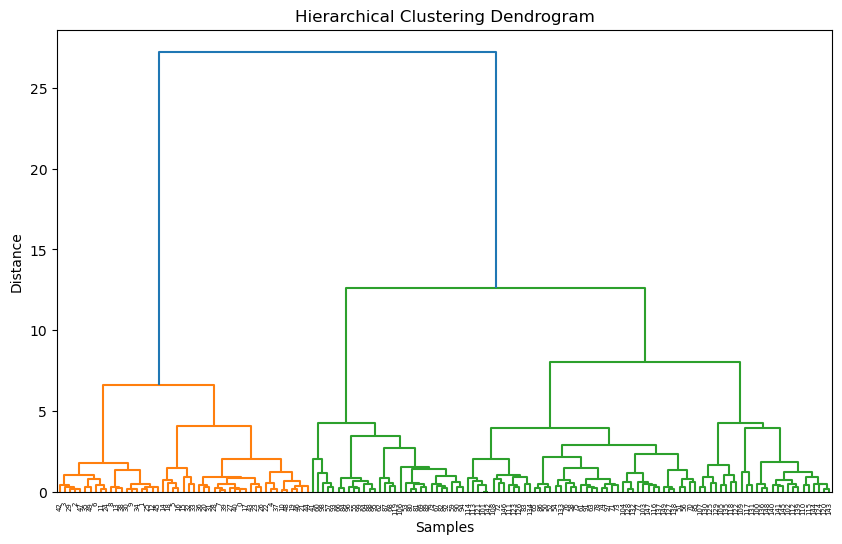

In [77]:
agg_labels = apply_agglomerative(X)
kmeans_labels = apply_kmeans(X)

agg_ari = evaluate_ari(y, agg_labels)
kmeans_ari = evaluate_ari(y, kmeans_labels)

print(f"Agglomerative Clustering ARI: {agg_ari:.4f}")
print(f"K-Means ARI: {kmeans_ari:.4f}")

plot_dendrogram(X)

### Compare with K-Means: which gives better ARI?

- In my experiment, K-means gave a higher ARI than Agglormerative clustering on the Iris flower data set dataset. This means hierarchical clustering matched the true classes slightly better in this run. The difference happens because K-Means depends on centroid initialization, while Agglomerative Clustering gives a fixed result